In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:




#input_dir = 'bootstrap-toy-study8b-1d-2a-total-fluctuations'

#input_dir = 'bootstrap-all-in-one-inspect-of-1d-7a'

input_dir = 'bootstrap-ensemble-1d-1c'



In [3]:
with open( '%s/correlations.npy' % input_dir, 'rb') as f :
    all_points_df0 = np.load(f)
    #all_points_df1 = np.load(f)
    all_points_dr = np.load(f)
    all_points_corr_array = np.load(f)


In [4]:
print("\n\n\n")
print("  all_points_df0 shape:  %s" % str(all_points_df0.shape))
print("  all_points_corr_array shape:  %s" % str(all_points_corr_array.shape))
print("\n\n\n")





  all_points_df0 shape:  (1000000,)
  all_points_corr_array shape:  (1000000,)






In [5]:
with open( '%s/correlation-points-feature-coords.npy' % input_dir, 'rb') as f :
    all_points_f0b = np.load(f)
    #all_points_f1b = np.load(f)
    all_points_coords = np.load(f)

In [6]:
all_points_coords[0]

array([1.62434536])

In [7]:
all_points_coords[1000]

array([1.62434536])

## Remove the points with correlation = 1 (self pairs)

In [8]:
mask =  (all_points_corr_array<0.99999) 

all_points_corr_array = all_points_corr_array[mask]
print(" shape of array after mask: %s" % str(all_points_corr_array.shape))

all_points_df0 = all_points_df0[mask]
#all_points_df1 = all_points_df1[mask]
all_points_dr = all_points_dr[mask]

all_points_f0b = all_points_f0b[mask]
#all_points_f1b = all_points_f1b[mask]

all_points_coords = all_points_coords[mask]


 shape of array after mask: (997580,)


In [9]:
mask

array([False,  True,  True, ...,  True,  True, False])

In [10]:
np.max(all_points_corr_array)

0.9999899942814968

<function matplotlib.pyplot.show(close=None, block=None)>

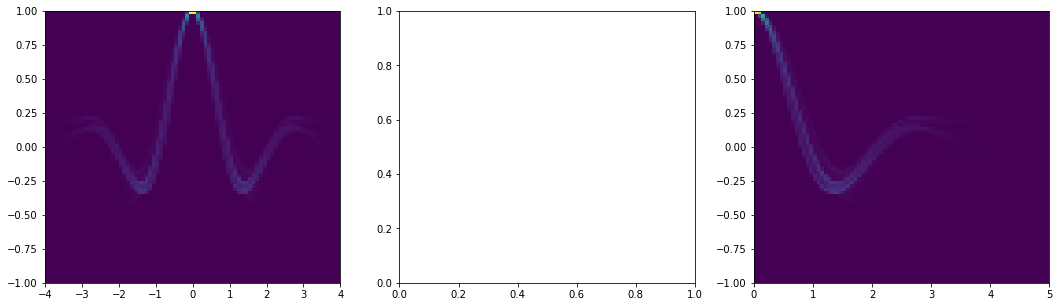

In [11]:
fig,ax = plt.subplots( 1, 3, figsize=(18,5))
ax[0].hist2d( all_points_df0, all_points_corr_array, bins=[80,80], range=([-4,4],[-1,1]))
#ax[1].hist2d( all_points_df1, all_points_corr_array, bins=[80,80], range=([-4,4],[-1,1]))
ax[2].hist2d( all_points_dr, all_points_corr_array, bins=[80,80], range=([0,5],[-1,1]))

#plt.savefig('correlation-vs-distance.png', bbox_inches='tight')
#plt.savefig('correlation-vs-distance.pdf', bbox_inches='tight')

plt.show

In [12]:
import matplotlib as mpl

<function matplotlib.pyplot.show(close=None, block=None)>

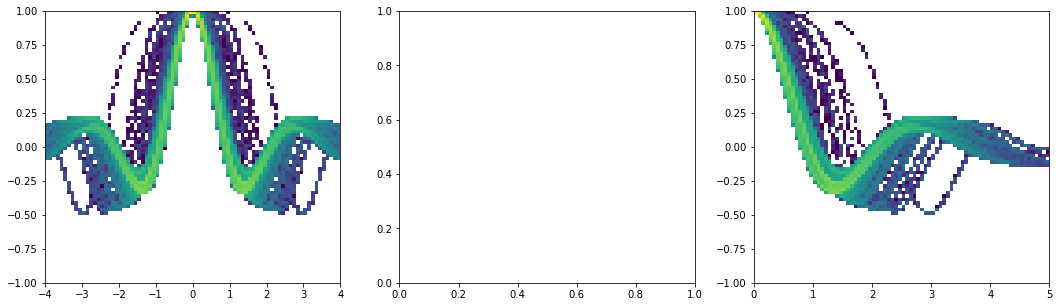

In [13]:
fig,ax = plt.subplots( 1, 3, figsize=(18,5))
ax[0].hist2d( all_points_df0, all_points_corr_array, bins=[80,80], norm=mpl.colors.LogNorm(), range=([-4,4],[-1,1]))
#ax[1].hist2d( all_points_df1, all_points_corr_array, bins=[80,80], norm=mpl.colors.LogNorm(), range=([-4,4],[-1,1]))
ax[2].hist2d( all_points_dr, all_points_corr_array, bins=[80,80], norm=mpl.colors.LogNorm(), range=([0,5],[-1,1]))

#plt.savefig('correlation-vs-distance.png', bbox_inches='tight')
#plt.savefig('correlation-vs-distance.pdf', bbox_inches='tight')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

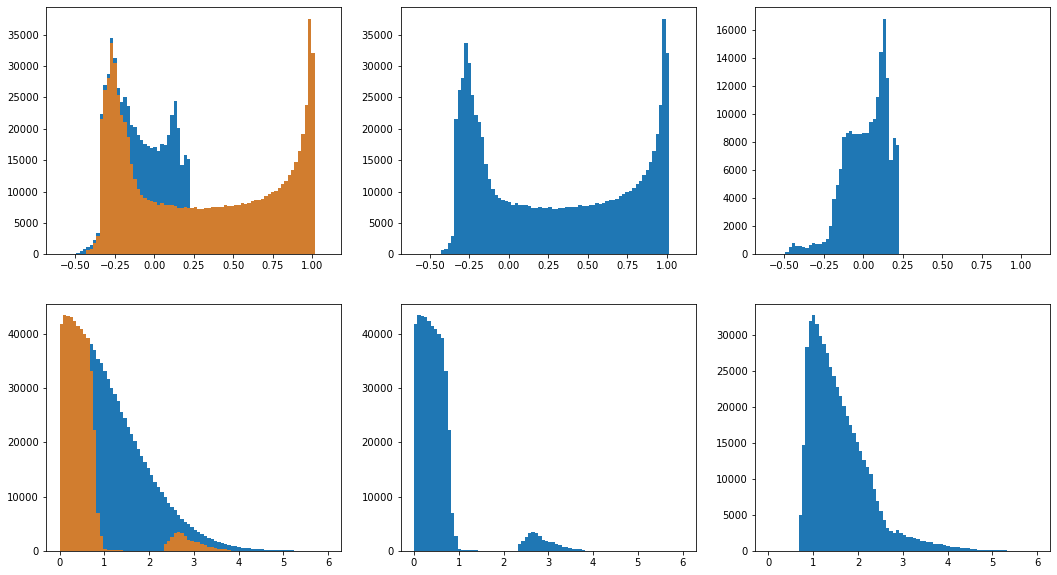

In [14]:
fig,ax = plt.subplots( 2, 3, figsize=(18,10))

hbins=80
hmax_dr = 6
min_cor = -0.6
max_cor = 1.1

dr_cut = 1.8
cor_cut = 0.15

ax[0][0].hist( all_points_corr_array, bins=hbins, range=[min_cor,max_cor])
ax[0][0].hist( all_points_corr_array[all_points_dr<dr_cut], bins=hbins, range=[min_cor,max_cor], alpha=0.8)
#ax[0][0].set_yscale('log')

ax[0][1].hist( all_points_corr_array[all_points_dr<dr_cut], bins=hbins, range=[min_cor,max_cor])

ax[0][2].hist( all_points_corr_array[all_points_dr>dr_cut], bins=hbins, range=[min_cor,max_cor])





ax[1][0].hist( all_points_dr, bins=hbins, range=[0,hmax_dr])
ax[1][0].hist( all_points_dr[all_points_corr_array>cor_cut], bins=hbins, range=[0,hmax_dr], alpha=0.8)

ax[1][1].hist( all_points_dr[all_points_corr_array>cor_cut], bins=hbins, range=[0,hmax_dr])

ax[1][2].hist( all_points_dr[all_points_corr_array<cor_cut], bins=hbins, range=[0,hmax_dr])




plt.show

In [15]:
num_total = len(all_points_dr)
num_large_correlation = len(all_points_dr[all_points_corr_array>cor_cut])
frac_large_correlation = (1.*num_large_correlation)/(1.*num_total)
print("\n\n Fraction with large correlations:  %d / %d = %.4f\n\n" % 
      (num_large_correlation, num_total,frac_large_correlation ) )



 Fraction with large correlations:  472776 / 997580 = 0.4739




In [16]:
def profile2d( axis, xvals, yvals, hbins, hrange, drawhist=True, drawline=True ) :
    
    hist_data = axis.hist2d( xvals, yvals, bins=hbins, range=hrange)
    
    if not drawhist :
        ax.cla()

    nybins = len(hist_data[0][0])
    print("number of y bins: %d" % nybins)

    nxbins = len(hist_data[0])
    print("number of x bins: %d" % nxbins)



    x_vals = np.zeros( nxbins )
    avey_vals = np.zeros( nxbins )
    rmsy_vals = np.zeros( nxbins )

    for xbi in range( nxbins ) :

        wsum = 0
        ywsum = 0
        yywsum = 0

        xval = 0.5 * ( hist_data[1][xbi] + hist_data[1][xbi+1] )
        #print(" xbin %d has center at %6.3f" % ( xbin_ind, xval ))

        for ybi in range( nybins ) :  
            yval = 0.5 * ( hist_data[2][ybi] + hist_data[2][ybi+1] )
            bin_content = hist_data[0][xbi][ybi]
            wsum = wsum + bin_content
            ywsum = ywsum + yval * bin_content
            yywsum = yywsum + yval * yval * bin_content
            #print("  %3d : y = %6.3f  bin content = %7d" % (bi, yval, bin_content))

        ave_y = ywsum / wsum
        ave_yy = yywsum / wsum
        rms_y = ave_yy - ave_y * ave_y
        #print(" Ave y = %.3f, RMS y = %.3f" % ( ave_y, rms_y) )

        x_vals[xbi] = xval
        avey_vals[xbi] = ave_y
        rmsy_vals[xbi] = rms_y


    #for xbi in range( nxbins ) :
        #print("  %4d :  x = %7.3f   ave y = %7.3f  rms y = %7.3f" % ( xbi, x_vals[xbi], avey_vals[xbi], rmsy_vals[xbi]))

    if drawline :
        ax.plot( (hist_data[1][0], hist_data[1][-1]), (0,0) )  
    
    ax.errorbar( x_vals, avey_vals, yerr=rmsy_vals, fmt='-o')
    
    plt.show
    
    return x_vals, avey_vals, rmsy_vals
    

number of y bins: 80
number of x bins: 80


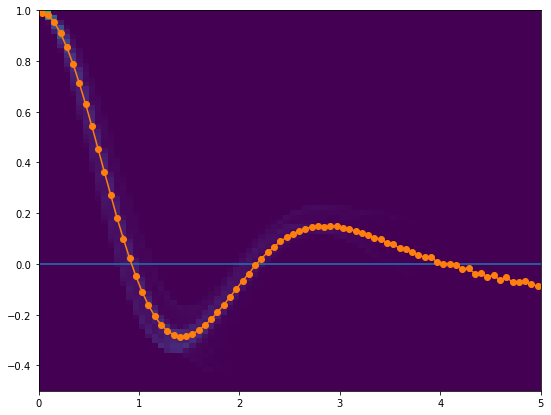

In [17]:
fig,ax = plt.subplots(1,1,figsize=(9,7))

a,b,c = profile2d( ax, all_points_dr, all_points_corr_array, hbins=[80,80], hrange=([0,5],[-0.5,1]), drawhist=True)

number of y bins: 80
number of x bins: 80


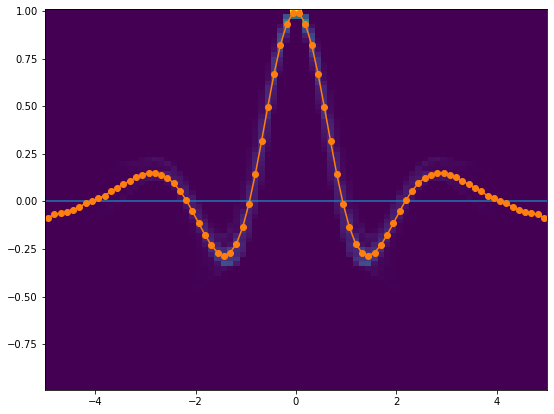

In [18]:
fig,ax = plt.subplots(1,1,figsize=(9,7))

x_vals, avey_vals_0, rmsy_vals_0 = profile2d( 
    ax, all_points_df0, all_points_corr_array, hbins=[80,80], hrange=([-5,5],[-0.99,1.01]), drawhist=True)

<function matplotlib.pyplot.show(close=None, block=None)>

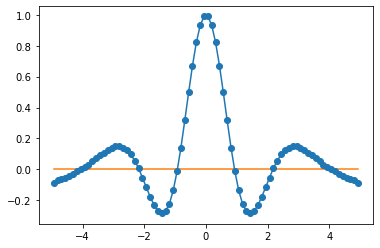

In [19]:
plt.errorbar( x_vals, avey_vals_0, yerr=rmsy_vals_0, fmt='-o')
plt.plot( x_vals, np.zeros(len(x_vals)))
plt.show 

<function matplotlib.pyplot.show(close=None, block=None)>

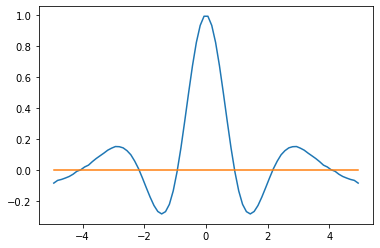

In [20]:
plt.plot( x_vals, avey_vals_0 )
plt.plot( x_vals, np.zeros(len(x_vals)))
plt.show 

## Calculate radial distance from model center

In [21]:
all_points_coords.shape

(997580, 1)

In [22]:
import pickle
with open( '%s/config-pars.pkl' % input_dir, 'rb') as f :
    train_mu = pickle.load(f)
    train_rho = pickle.load(f)
    train_sig = pickle.load(f)
    true_mu = pickle.load(f)
    true_rho = pickle.load(f)
    true_sig = pickle.load(f)
    resolution = pickle.load(f)
    train_cov = pickle.load(f)
    true_cov = pickle.load(f)

In [23]:
import read_config_utils as cu
ndim = int(cu.get_par( '%s/config.txt' % (input_dir), "ndim"))
print("\n\n Number of feature dimensions: %d\n\n" % ndim)



 Number of feature dimensions: 1




In [24]:
true_mu

[0.2]

In [25]:
all_points_model_r2 = np.zeros( len(all_points_coords) )
for fi in range(ndim) :
    delta_fi = all_points_coords[:,fi] - true_mu[fi]
    all_points_model_r2 += delta_fi * delta_fi
all_points_model_r = np.sqrt( all_points_model_r2 )

<function matplotlib.pyplot.show(close=None, block=None)>

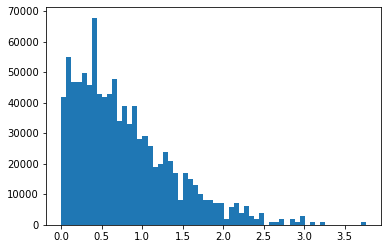

In [26]:
plt.hist( all_points_model_r, bins=60)
plt.show

In [27]:
all_points_model_r.shape

(997580,)

In [28]:
all_points_corr_array.shape

(997580,)

<function matplotlib.pyplot.show(close=None, block=None)>

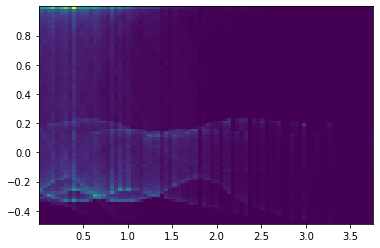

In [29]:
plt.hist2d( all_points_model_r, all_points_corr_array, bins=[80,80])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

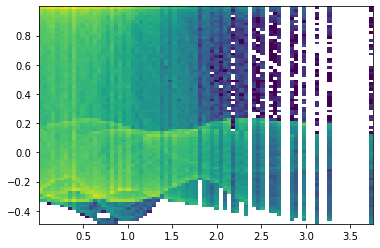

In [30]:
plt.hist2d( all_points_model_r, all_points_corr_array, bins=[80,80], norm=mpl.colors.LogNorm())
plt.show

number of y bins: 80
number of x bins: 80


/tmp/ipykernel_3082391/269159330.py:37: RuntimeWarning: invalid value encountered in scalar divide
  ave_y = ywsum / wsum
/tmp/ipykernel_3082391/269159330.py:38: RuntimeWarning: invalid value encountered in scalar divide
  ave_yy = yywsum / wsum


(array([0.03125, 0.09375, 0.15625, 0.21875, 0.28125, 0.34375, 0.40625,
        0.46875, 0.53125, 0.59375, 0.65625, 0.71875, 0.78125, 0.84375,
        0.90625, 0.96875, 1.03125, 1.09375, 1.15625, 1.21875, 1.28125,
        1.34375, 1.40625, 1.46875, 1.53125, 1.59375, 1.65625, 1.71875,
        1.78125, 1.84375, 1.90625, 1.96875, 2.03125, 2.09375, 2.15625,
        2.21875, 2.28125, 2.34375, 2.40625, 2.46875, 2.53125, 2.59375,
        2.65625, 2.71875, 2.78125, 2.84375, 2.90625, 2.96875, 3.03125,
        3.09375, 3.15625, 3.21875, 3.28125, 3.34375, 3.40625, 3.46875,
        3.53125, 3.59375, 3.65625, 3.71875, 3.78125, 3.84375, 3.90625,
        3.96875, 4.03125, 4.09375, 4.15625, 4.21875, 4.28125, 4.34375,
        4.40625, 4.46875, 4.53125, 4.59375, 4.65625, 4.71875, 4.78125,
        4.84375, 4.90625, 4.96875]),
 array([ 0.34039785,  0.33833047,  0.33758214,  0.33532307,  0.32802332,
         0.32729517,  0.31933963,  0.30817999,  0.29649129,  0.28481187,
         0.27089738,  0.25578636,  0

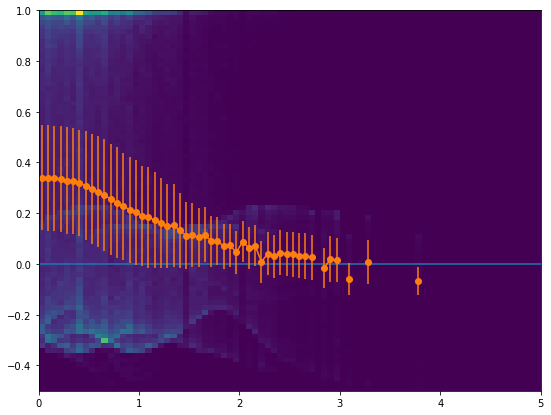

In [31]:
fig,ax = plt.subplots(1,1,figsize=(9,7))

profile2d( ax, all_points_model_r, all_points_corr_array, hbins=[80,80], hrange=([0,5],[-0.5,1]), drawhist=True)

In [32]:
all_points_dr

array([2.23610178, 2.15251712, 2.69731399, ..., 2.09034298, 0.11733048,
       0.54082544])

In [33]:
all_points_model_r

array([0.81175641, 0.72817175, 1.27296862, ..., 2.477298  , 0.26962454,
       0.15387043])

In [34]:
all_points_model_r[0]

0.8117564136500754

In [35]:
all_points_coords[0]

array([-0.61175641])

In [36]:
all_points_model_r[1]

0.7281717522634557

In [37]:
all_points_coords[1]

array([-0.52817175])

<function matplotlib.pyplot.show(close=None, block=None)>

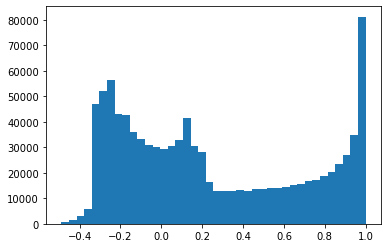

In [38]:
plt.hist( all_points_corr_array, bins=40)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

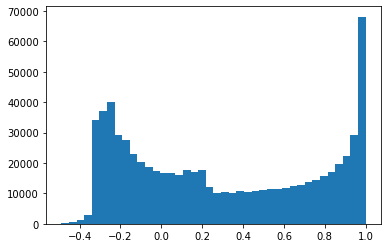

In [39]:
plt.hist( all_points_corr_array[all_points_model_r<1], bins=40)
plt.show

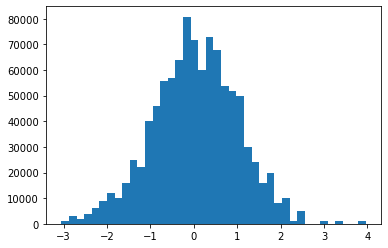

In [40]:
plt.hist( all_points_coords[:,0], bins=40)
plt.show()

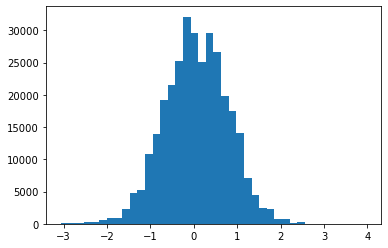

In [41]:
plt.hist( all_points_coords[:,0][all_points_corr_array>0.5], bins=40)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

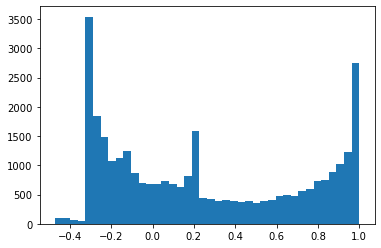

In [42]:
plt.hist( all_points_corr_array[(all_points_coords[:,0]>0.8) & (all_points_coords[:,0]<0.9)], bins=40)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

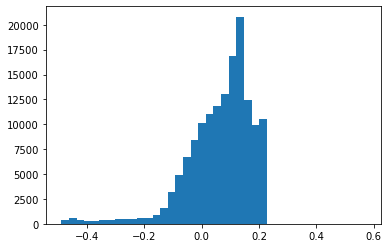

In [43]:
plt.hist( all_points_corr_array[ np.abs(all_points_df0)>2], bins=40)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

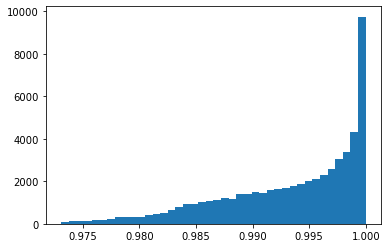

In [44]:
plt.hist( all_points_corr_array[ np.abs(all_points_df0)<0.1], bins=40)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

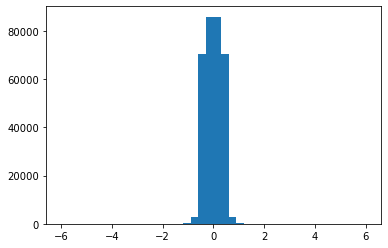

In [45]:
plt.hist( all_points_df0[ all_points_corr_array>0.5], bins=40, range=[-6,6])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

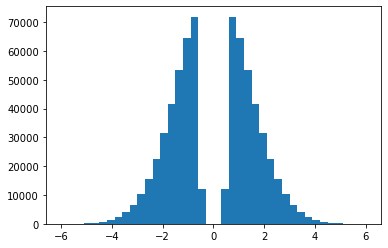

In [46]:
plt.hist( all_points_df0[ all_points_corr_array<0.5], bins=40, range=[-6,6])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

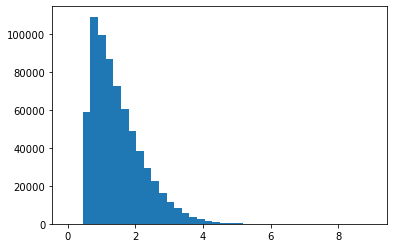

In [47]:
plt.hist( all_points_dr[ all_points_corr_array<0.5], bins=40, range=[0,9])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

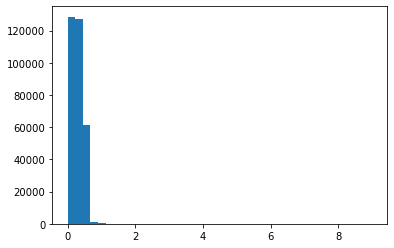

In [48]:
plt.hist( all_points_dr[ all_points_corr_array>0.5], bins=40, range=[0,9])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

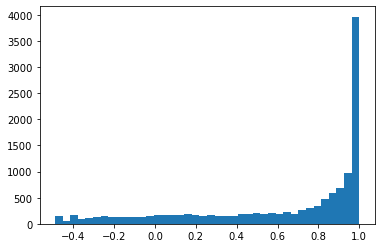

In [49]:
plt.hist( all_points_corr_array[ (all_points_df0<0.1) & (all_points_coords[:,0]>0.8) & (all_points_coords[:,0]<1.0)], bins=40)
plt.show

In [50]:
all_points_df0.shape

(997580,)